<a href="https://colab.research.google.com/github/isamontec/Analitica-de-Negocios/blob/main/Reto_Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Isabella Montenegro*

#*CASO DE ESTUDIO*

Una entidad del sector Salud, quiere implementar un modelo para la clasificación de  pacientes que poseen diabetes en función de sus variables de salud, para lo cual la entidad dispone de la siguiente base de datos (diabetes.csv) donde implementaremos modelos claves como lo son Naive Bayes, Árbol de Decisión, y Clustering K-Means, donde analizaremo  la correlación, esto con el fin de identificar cuales son las variables de entrada que poseen una mayor correlación, así como con la correlación entre las variables de entrada y la variable de salida.

Varables:


*   Preganancies = Número de veces que la paciente ha estado embarazada.
*   Glucose = Nivel de glucosa en sangre después de una prueba oral de tolerancia a la glucosa.
* BloodPressure = Presion arterial diastolica.
* SkinThickness = Grosor del pliegue de la piel de los triceps, usado para estimar grasa corporal.
* Insulin = Nivel de insulina en sangre (2 horas después de la prueba de glucosa).
* BMI = Refleja la relación entre peso y estatura, y permite identificar sobrepeso u obesidad.
* DiabetesPedigreeFunction = mide la probabilidad genética de que una persona tenga diabetes basada en su historial familiar.
* Age = Indica el numero de años que posee una persona.
* Outcome = Resultado del diagnóstico: 0 = no tiene diabetes, 1 = tiene diabetes.



En el modelo de Naive Bayes, identificando los limites superiores e inferiores para cada una de las variables. Es importante por clasificación de diabetes, cual grupo posee mayores o menores valores frente a las variables de entrada.

Para el árbol de decisión, y desplegar las reglas que componen el árbol para la clasificación de los pacientes por nivel de diabetes. Es importante para el análisis identificar el número de nodos puros, y describir para uno de los nodos puros cual posee el mayor número de datos, y cuál es la regla del negocio.

y para finalizar construyendo el modelo de Clusterización K-Means a cinco grupos de clasificación. Determinar la probabilidad de que un paciente tenga diabetes para cada uno de los clusters de agrupación.




**0. Procedemos a cargar las librerias de trabajo**

In [ ]:
import numpy as np
import pandas as pd

#Librerias especificas Naive Buyes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

#Librerias especificas árboles de decision
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

#Librerias especificas K-Means
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

1. Se carga la base de datos para el trabajo

In [ ]:
nxl='/content/diabetes.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XD=XDB.iloc[:,8]
yd=XDB.iloc[:,8]

#2. Realizamos correlación

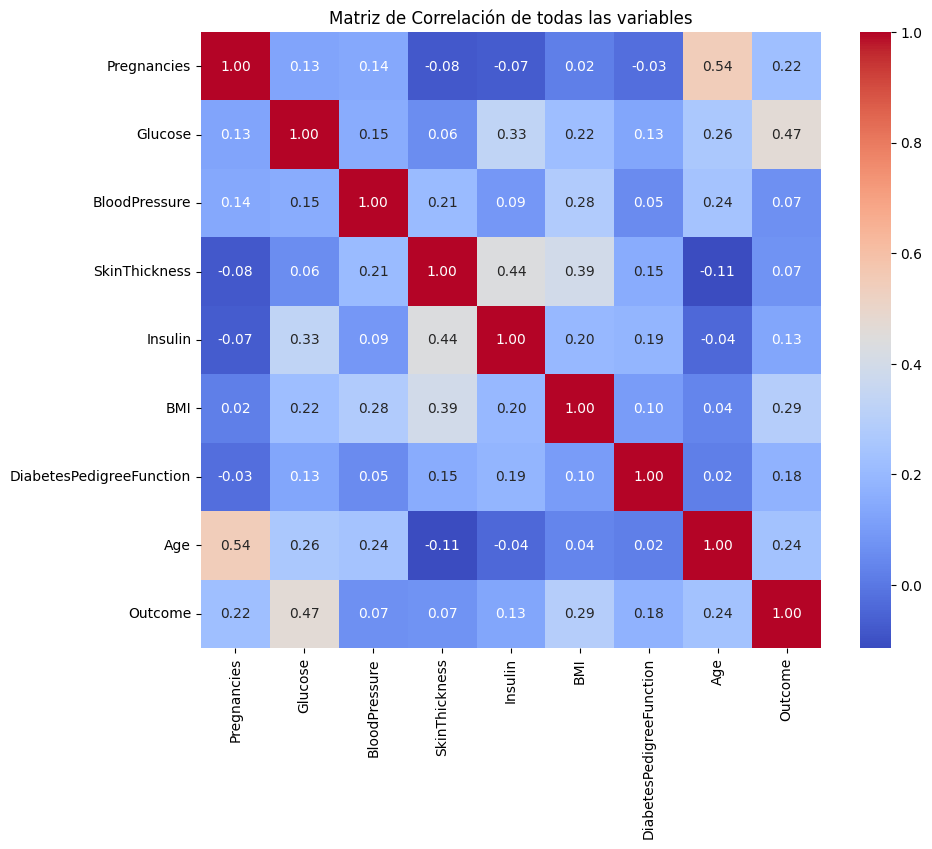

In [ ]:
correlation_matrix_all = XDB.corr(numeric_only=True)

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de todas las variables')
plt.show()

#ANALISIS CORRELACCION

En la gráfica del heatmap de correlación se puede observar que la relación más fuerte entre variables independientes es la de Pregnancies y Age con una correlación de 0.54. Esto indica que a mayor edad, es más probable que la persona haya tenido más embarazos, lo cual es lógico porque con el paso del tiempo aumenta la posibilidad de haber estado embarazada más veces.

Otra correlación relevante es la relación entre SkinThickness e Insulin (0.44). Esto sugiere que las personas con mayor espesor del pliegue cutáneo (mayor grasa corporal) tienden a presentar niveles más altos de insulina.

También se observa una correlación moderada entre BMI y SkinThickness (0.39), lo cual indica que cuando el índice de masa corporal aumenta, también tiende a aumentar el espesor del pliegue cutáneo, lo que refleja una relación con el nivel de grasa corporal.

En cuanto a la variable de salida (Outcome), la variable que presenta la mayor correlación es Glucose (0.47). Esto significa que niveles altos de glucosa en sangre están fuertemente asociados con la presencia de diabetes.

Otras variables que también muestran cierta relación con el resultado son BMI (0.29) y Age (0.24), lo que sugiere que un mayor índice de masa corporal y una mayor edad pueden aumentar la probabilidad de desarrollar diabetes.

En general, el nivel de glucosa es la variable más importante para predecir la diabetes, seguido por factores como el BMI y la edad, mientras que otras variables presentan correlaciones más bajas.

#3. Modelo Naive Buyes

Seleccionamos Variables de trabajo

In [ ]:
XD=XDB[["Pregnancies","Glucose", "BloodPressure","SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]] #Variables de trabajo
XDB.head(10)
yd=XDB["Outcome"] # Changed to a Series
yd.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


4. Implementación del Modelo Naive Buyes

In [ ]:
from sklearn.model_selection import train_test_split

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(XD, yd, test_size=0.3, random_state=42)

mnb=GaussianNB()
mnb.fit(X_train_nb, y_train_nb) # Ajustar Variables Entrada - Salida con datos de entrenamiento

#Mostramos las medias
u=mnb.theta_
sigma=mnb.var_;sigma=np.sqrt(sigma)
print("Medias (theta_) para cada clase:\n", u)
print ("Desviaciones estándar (sigma_) para cada clase:\n", sigma)

# Imprimir los nombres de las características para claridad
feature_names = XD.columns.tolist()
print("Orden de las características:\n", feature_names)

Medias (theta_) para cada clase:
 [[  3.25501433 109.50143266  68.19484241  19.78223496  68.40401146
   30.16590258 396.01939828  30.67621777]
 [  4.60106383 141.91489362  72.45212766  21.63829787 101.05851064
   35.33510638 503.59420213  37.52659574]]
Desviaciones estándar (sigma_) para cada clase:
 [[  2.97089327  25.58111386  17.58343134  14.56449861  95.17897598
    7.24224844 327.85149905  11.3084464 ]
 [  3.57674423  32.9264704   18.64742753  16.97423378 142.56361736
    7.14195395 374.80580882  11.01857472]]
Orden de las características:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


5. Se procede con la evaluación del modelo. Para la evaluación de este tipo de modelos se utiliza la matriz de confusión.

In [ ]:
ydp=mnb.predict(X_test_nb) # Realizar predicciones en el conjunto de prueba
cm=confusion_matrix(y_test_nb, ydp)
print("Matriz de Confusión:\n", cm)

#Se determinan las metricas de la matriz de confusion
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(y_test_nb)

#1. Exactitud: Funcionamiento general del modelo
Ex=(VP+VN)/TDatos
print("Exactitud=",Ex)

#2. Tasa Error: %Fallos del modelo
TE=(FP+FN)/TDatos
print("Tasa Error=",TE)

#3.Sensibilidad: Como se comparto con respectos a los Verdaderos Positivos
Se=VP/(VP+FN)
print("Sensibilidad:", Se)

#4.Especificidad: como se comporta el pronostico negativos
Es=VN/(VN+FP)
print("Especificidad:", Es)

#5.Precision: Es una version de como se comporta el modelo frente a los positivos solamente

Pre=VP/(VP+FP)
print("Precision:", Pre)

#6.Prediccion Negativa: Como funciona el modelo pronosticando negativos

PreN=VN/(VN+FN)
print("Prediccion Negativa:", PreN)

Matriz de Confusión:
 [[119  32]
 [ 27  53]]
Exactitud= 0.7445887445887446
Tasa Error= 0.2554112554112554
Sensibilidad: 0.6625
Especificidad: 0.7880794701986755
Precision: 0.6235294117647059
Prediccion Negativa: 0.815068493150685


6. Evaluamos un paciente

In [ ]:
XDp=[2,85,65,29,94,39.6,0.93,27] # Esta lista tiene 8 características, coincidiendo con XD
ydc=mnb.predict([XDp])
print(f"El modelo predice: {ydc}")

if ydc[0] == 1:
    print("El paciente es: Diabético")
else:
    print("El paciente es: No Diabético")

El modelo predice: [0]
El paciente es: No Diabético


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


# ANALISI DE RESULTADO MODELO NAIVE BUYES
En los resultados del modelo se presentan las medias (theta) y desviaciones estándar (sigma) de cada variable para las dos clases del problema: personas sin diabetes (0) y personas con diabetes (1).

Al analizar las medias se observa que las personas con diabetes presentan valores más altos en variables clave como Glucose (141.9 vs 109.5), BMI (35.33 vs 30.16), Insulin (101.05 vs 68.40) y Age (37.52 vs 30.67). Esto indica que los pacientes con diabetes tienden a tener mayores niveles de glucosa, mayor índice de masa corporal, mayor insulina y mayor edad, lo cual coincide con los factores de riesgo conocidos para esta enfermedad.


En cuanto al desempeño del modelo, la matriz de confusión muestra que el modelo clasificó correctamente 119 casos negativos (personas sin diabetes) y 53 casos positivos (personas con diabetes). Sin embargo, también cometió errores al clasificar 32 falsos positivos y 27 falsos negativos.

La exactitud del modelo es de 74.45%, lo que significa que aproximadamente 3 de cada 4 predicciones fueron correctas. La tasa de error es de 25.54%, lo que representa los casos en los que el modelo se equivocó.

La sensibilidad (0.6625) indica que el modelo logra identificar correctamente aproximadamente 66% de las personas que realmente tienen diabetes. Por otro lado, la especificidad (0.788) muestra que el modelo identifica correctamente cerca del 79% de las personas que no tienen diabetes.

Finalmente, la precisión (0.62) indica que cuando el modelo predice que una persona tiene diabetes, acierta alrededor del 62% de las veces, mientras que la predicción negativa (0.815) muestra que cuando el modelo predice que una persona no tiene diabetes, acierta aproximadamente el 81.5% de las veces.

Adicionalmente, se realizó el diagnóstico de un paciente utilizando el modelo entrenado. El resultado de la predicción fue [0], lo que significa que el modelo clasifica al paciente como No Diabético. Esto indica que, según los patrones aprendidos por el modelo y las variables ingresadas del paciente, no se detecta una alta probabilidad de presencia de diabetes.

En general, el modelo presenta un desempeño aceptable, con mejor capacidad para identificar correctamente a las personas sin diabetes que a las personas con diabetes, lo cual se refleja en una mayor especificidad que sensibilidad.

#7. Implementación del Modelo Árbol de Decisión

8. datos de trabajo

In [ ]:
nxl='/content/diabetes.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XD=XDB.iloc[:,8]
yd=XDB.iloc[:,8]
display(XD)

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


9. se implementa el modelo

In [ ]:
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd) # Aquí el modelo busca la relacion entrada?/salida

# Y que fue lo que hizo el modelo?

ydp=mar.predict(XD) # Esto es lo que pronóstica el modelo
#Se construye la matriz de confusion
cm=confusion_matrix(yd,ydp)
display(cm)
VN=cm[0,0]; FP=cm[0,1];FN=cm[1,0]; VP=cm[1,1]

#metricas de desempeño
exactitud=(VP+VN)/(VP+VN+FP+FN) #1.comportamiento general
print('La exactitud es:',exactitud)
sensibilidad=VP/(VP+FN) #2.Como se comporta pronosticando Positivos
print('La sensibilidad es:',sensibilidad)
especificidad=VN/(VN+FP) #3. Como se comporta frente a los negativos
print('La especificidad es:',especificidad)
precision=VP/(VP+FP) #4. Como se comporta pronosticando Positivos
print('La precision es:',precision)
preneg=VN/(VN+FN) #5. Como se comporta pronosticando negativos
print('La prenegatividad es:',preneg)

array([[459,  41],
       [119, 149]])

La exactitud es: 0.7916666666666666
La sensibilidad es: 0.5559701492537313
La especificidad es: 0.918
La precision es: 0.7842105263157895
La prenegatividad es: 0.7941176470588235


10. despliegue del arbol de decisión

In [ ]:
from sklearn.tree import export_graphviz # exporta los datos a un grafico
from pydotplus import graph_from_dot_data # es un graficador

vs=["Pregnancies","Glucose", "BloodPressure","SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"] #titulos del arbol

dot_data=export_graphviz(mar,feature_names=vs) #exportar de numeros a graficos en pdf
graph=graph_from_dot_data(dot_data) #hacemos el grafico
graph.write_png('arbol.png')

True

#ANALISS DE RESULTADO MODELO ÀRRBOL DE DECISIÓN

En el modelo de árbol de decisión se observa que la primera variable utilizada para dividir los datos es Glucose ≤ 127.5, lo que indica que el nivel de glucosa en sangre es el factor más importante para clasificar si un paciente tiene diabetes o no. En el nodo raíz se tienen 768 muestras, donde 500 corresponden a pacientes no diabéticos y 268 a pacientes diabéticos, con un índice gini de 0.454, lo que indica cierta mezcla entre las clases.

A partir de esta primera división, el árbol continúa separando los pacientes utilizando principalmente variables como Age, BMI, Insulin y nuevamente Glucose, lo que muestra que estas variables tienen una alta relevancia para determinar el riesgo de diabetes.

Por ejemplo, cuando Glucose ≤ 127.5 y Age ≤ 28.5, el modelo continúa evaluando el BMI, indicando que el índice de masa corporal es un factor importante para pacientes jóvenes. Por otro lado, cuando Glucose > 127.5, el árbol analiza variables como BMI y niveles de insulina, lo que sugiere que en pacientes con glucosa alta se requieren más variables para determinar con mayor precisión el diagnóstico.

Dentro del árbol se identifican varios nodos puros (gini = 0), lo que significa que todos los pacientes en ese nodo pertenecen a una sola clase, por lo que el modelo logra una clasificación perfecta en esos casos. En el árbol se pueden identificar aproximadamente 6 nodos puros, donde el modelo clasifica completamente a los pacientes como diabéticos o no diabéticos.
El nodo puro con mayor número de datos es el que presenta 39 muestras con valor [39,0], lo que indica que todos los pacientes en ese nodo son no diabéticos.

La regla de negocio asociada a este nodo sería:

Si Glucose ≤ 127.5

y Age ≤ 28.5

y BMI ≤ 26.35

y BMI ≤ 9.65

Entonces el paciente es clasificado como No Diabético.

Esta regla indica que pacientes jóvenes con niveles bajos de glucosa y un índice de masa corporal bajo tienen muy baja probabilidad de desarrollar diabetes.


El árbol muestra que las variables Glucose, BMI, Age e Insulin son las más influyentes en la clasificación. El modelo construye reglas claras y fáciles de interpretar, lo que permite entender las condiciones bajo las cuales un paciente puede ser clasificado como diabético o no, facilitando la interpretación médica del modelo.

#11. Modelo Clusterización K-means

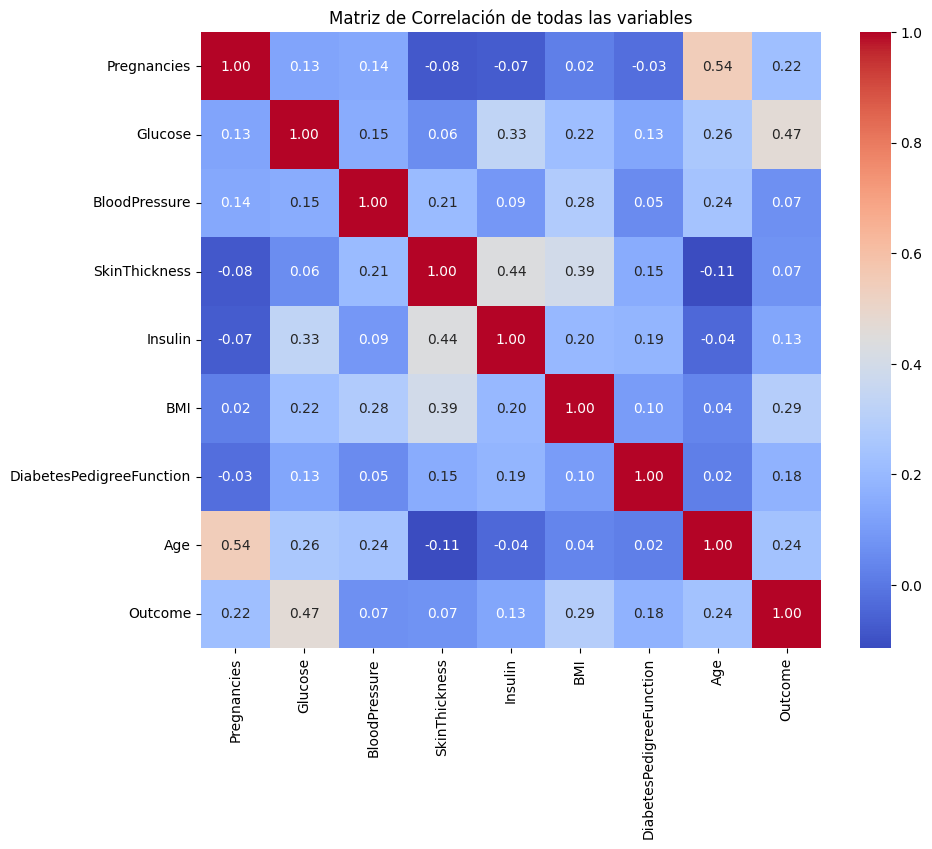

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de todas las variables')
plt.show()

12. implementacion del modelo K-means

In [ ]:
np.random.seed(42) #Permite generar las mismas semillas para todos
NC=5# 5 segmentos o perfiles de clientes

XD_features = XDB[["Pregnancies","Glucose", "BloodPressure","SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]

mkm=KMeans(n_clusters=NC,random_state=42, n_init=10)
mkm.fit(XD_features) # El modelo de K-Means solo busca patrones en los datos de entrada (XD)

#Obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las personas mkm.cluster_centers_ que encontro el modelo
tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD_features.columns)
display(tabla)

#Para saber los porcentajes de positivos o negativos por segmento, sucursal o perfil
ydp=mkm.labels_ #Esto me indica en que cluster esta clasificado cada dato
NDc=np.bincount(ydp) #numero de datos por segmento
print("El numero de datos por cluster es:",NDc)

# Añadimos la columna del cluster al DataFrame original para análisis posterior
XDB['Cluster'] = ydp

# Calcular la probabilidad de diabetes para cada cluster
# La variable 'Outcome' es 1 para diabetes y 0 para no diabetes
diabetes_probability = XDB.groupby('Cluster')['Outcome'].mean()
print("\nProbabilidad de diabetes por cluster:")
print(diabetes_probability)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.176471,117.750000,65.941176,16.975490,55.808824,30.960294,100.958578,33.303922
1,3.853535,124.085859,68.707071,23.378788,115.550505,32.856061,647.656566,33.646465
2,3.613559,119.169492,70.867797,19.959322,66.254237,31.590847,323.115254,32.725424
3,1.375000,140.625000,66.500000,28.250000,197.625000,31.675000,1944.500000,29.000000
4,4.142857,126.619048,72.682540,24.857143,93.587302,34.542857,1098.063492,34.714286


El numero de datos por cluster es: [204 198 295   8  63]

Probabilidad de diabetes por cluster:
Cluster
0    0.250000
1    0.424242
2    0.325424
3    0.375000
4    0.539683
Name: Outcome, dtype: float64


13. porcentajes de pacientes con diabetes


In [ ]:
NApr_counts = XDB.groupby('Cluster').agg({'Outcome': lambda x: (x == 1).sum()}).rename(columns={'Outcome': 'Diabetes_Count'})
NPrn_counts = XDB.groupby('Cluster').agg({'Outcome': lambda x: (x == 0).sum()}).rename(columns={'Outcome': 'No_Diabetes_Count'})
counts_by_cluster = NApr_counts.join(NPrn_counts)
counts_by_cluster['Total_Patients'] = counts_by_cluster['Diabetes_Count'] + counts_by_cluster['No_Diabetes_Count']

counts_by_cluster['Prob_Diabetes'] = counts_by_cluster['Diabetes_Count'] / counts_by_cluster['Total_Patients']
counts_by_cluster['Prob_No_Diabetes'] = counts_by_cluster['No_Diabetes_Count'] / counts_by_cluster['Total_Patients']

print("Número de pacientes con y sin diabetes por cluster:")
display(counts_by_cluster)

print("\nProbabilidad de diabetes y no diabetes por cluster (en formato similar a 'PreApr'/'PreNeg'):")
df2 = counts_by_cluster[['Prob_Diabetes', 'Prob_No_Diabetes']]
df2.columns = ['Diabetes_Prob', 'No_Diabetes_Prob']
display(df2)

Número de pacientes con y sin diabetes por cluster:


,Diabetes_Count,No_Diabetes_Count,Total_Patients,Prob_Diabetes,Prob_No_Diabetes
Cluster,,,,,
0,51,153,204,0.250000,0.750000
1,84,114,198,0.424242,0.575758
2,96,199,295,0.325424,0.674576
3,3,5,8,0.375000,0.625000
4,34,29,63,0.539683,0.460317



Probabilidad de diabetes y no diabetes por cluster (en formato similar a 'PreApr'/'PreNeg'):


,Diabetes_Prob,No_Diabetes_Prob
Cluster,,
0,0.250000,0.750000
1,0.424242,0.575758
2,0.325424,0.674576
3,0.375000,0.625000
4,0.539683,0.460317


14. Analizamos a una paciente especifico

In [ ]:
import warnings
warnings.filterwarnings('ignore')
nueva_persona=np.array([[2,85,65,29,94,39.6,0.93,27]])
ydp=mkm.predict(nueva_persona)
NCl=ydp [0]#esto indica el cluster al que pertenece una persona
print("La persona pertenece al cluster:",ydp)
# Accediendo a las probabilidades desde df2
print("El porcentaje de Diabetes para la nueva persona es:",df2['Diabetes_Prob'].iloc[NCl])
print("El porcentaje de No Diabetes para la nueva persona es:",df2['No_Diabetes_Prob'].iloc[NCl])

La persona pertenece al cluster: [0]
El porcentaje de Diabetes para la nueva persona es: 0.25
El porcentaje de No Diabetes para la nueva persona es: 0.75


15. Procedemos con la grafica de los clusters utilizando las variables

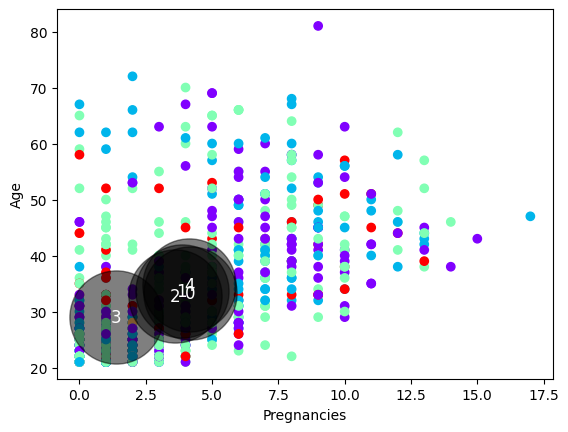

In [ ]:
centers=mkm.cluster_centers_ #centroides, perfil y segmento
ing=np.array(XD.iloc[:,0]); egr=np.array(XD.iloc[:,7])


plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap='rainbow')
plt.scatter(centers[:,0],centers[:,7],c='black',s=4500,alpha=0.5)
plt.xlabel("Pregnancies")
plt.ylabel("Age")

#ADD NUMBERS
for i, center in enumerate(centers):
    plt.text(center[0],center[7],str(i),color='white', fontsize=12, ha='center', va='center')
plt.show()

#ANALISIS DE RESULTADO K-MEANS

En la gráfica del heatmap de correlación se puede observar que la relación más fuerte entre variables es la de Pregnancies y Age con una correlación de 0.54, lo que indica que a mayor edad es más probable que una persona haya tenido más embarazos.

Otra correlación relevante es la relación entre SkinThickness e Insulin (0.44), lo que sugiere que cuando aumenta el espesor del pliegue cutáneo (indicador de grasa corporal), también tienden a aumentar los niveles de insulina.

También se observa una relación importante entre BMI y SkinThickness (0.39), lo que indica que personas con mayor índice de masa corporal tienden a presentar mayor grasa corporal.

En relación con la variable de salida (Outcome), la variable que presenta la mayor correlación es Glucose con un 0.47, lo que indica que los niveles altos de glucosa en sangre están fuertemente asociados con la presencia de diabetes. Otras variables que también muestran relación con el diagnóstico son BMI (0.29) y Age (0.24).

De acuerdo con los segmentos o clusters arrojados por el modelo K-Means, se identificaron 5 grupos de pacientes con características similares. El número de pacientes por cluster es: cluster 0 (204), cluster 1 (198), cluster 2 (295), cluster 3 (8) y cluster 4 (63).

Se destaca el cluster 4, el cual presenta la mayor probabilidad de diabetes con un 53.96%, siendo el grupo con mayor riesgo dentro de la segmentación. Este cluster agrupa pacientes con valores relativamente más altos en variables relacionadas con la enfermedad como glucosa, insulina y BMI, lo que aumenta la probabilidad de desarrollar diabetes.

El cluster 1 también presenta una probabilidad relativamente alta de diabetes con 42.42%, lo que indica un grupo con riesgo moderado de padecer la enfermedad.

Por otro lado, el cluster 2 presenta una probabilidad de diabetes de 32.54%, representando un grupo intermedio donde la mayoría de pacientes aún no presentan la enfermedad, pero existe cierto nivel de riesgo.

Se destaca el cluster 0, el cual agrupa 204 pacientes y presenta una probabilidad de diabetes de 25%, siendo uno de los grupos con menor riesgo. Esto indica que en este grupo predominan pacientes con características más saludables en variables como glucosa, BMI e insulina.

Finalmente, el cluster 3 es el grupo más pequeño con solo 8 pacientes y una probabilidad de diabetes de 37.5%, por lo que puede representar un grupo atípico o muy específico dentro de los datos.

Al analizar el caso de una nueva paciente, el modelo la clasifica dentro del cluster 0, donde la probabilidad estimada de diabetes es 25%, mientras que la probabilidad de no presentar diabetes es 75%, lo que sugiere que, según las características analizadas, la paciente tiene baja probabilidad de desarrollar diabetes.

Para concluir, el modelo de clusterización permite identificar diferentes perfiles de pacientes según sus características clínicas, destacando grupos con mayor o menor riesgo de diabetes, lo cual puede ser útil para segmentar pacientes y orientar estrategias de prevención o seguimiento médico.